# Introduction

Today we'll dive deep into a dataset all about LEGO. From the dataset we can ask whole bunch of interesting questions about the history of the LEGO company, their product offering, and which LEGO set ultimately rules them all:

<ul type="square">
<li>What is the most enormous LEGO set ever created and how many parts did it have?</li>

<li>How did the LEGO company start out? In which year were the first LEGO sets released and how many sets did the company sell when it first launched?</li>

<li>Which LEGO theme has the most sets? Is it one of LEGO's own themes like Ninjago or a theme they licensed liked Harry Potter or Marvel Superheroes?</li>

<li>When did the LEGO company really expand its product offering? Can we spot a change in the company strategy based on how many themes and sets did it released year-on-year?</li>

<li>Did LEGO sets grow in size and complexity over time? Do older LEGO
sets tend to have more or fewer parts than newer sets?</li>
</ul>

**Data Source**

[Rebrickable](https://rebrickable.com/downloads/) has compiled data on all the LEGO pieces in existence. I recommend you use download the .csv files provided in this lesson.

<img src="https://i.imgur.com/49FNOHj.jpg">

# Import Statements

In [9]:
import pandas as pd
import matplotlib.pyplot as plt


# Data Exploration

**Challenge**: How many different colours does the LEGO company produce? Read the colors.csv file in the data folder and find the total number of unique colours. Try using the [.nunique() method](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.nunique.html?highlight=nunique#pandas.DataFrame.nunique) to accomplish this.

In [19]:
colors = pd.read_csv("colors.csv", header=0)
print("antal unika färger", colors['rgb'].nunique())





antal unika färger 124


**Challenge**: Find the number of transparent colours where <code>is_trans == 't'</code> versus the number of opaque colours where <code>is_trans == 'f'</code>. See if you can accomplish this in two different ways.

In [11]:


print("antal transparenta", colors[colors['is_trans'] == 't']["rgb"].count())

#print("Antal transparenta eller inte transparenta", colors.is_trans.value_counts())


antal transparenta 28


**Challenge**: Change this into an h3 section heading: Understanding LEGO Themes vs. LEGO Sets

Walk into a LEGO store and you will see their products organised by theme. Their themes include Star Wars, Batman, Harry Potter and many more.

**Challenge**: Display this image: https://i.imgur.com/aKcwkSx.png

A lego set is a particular box of LEGO or product. Therefore, a single theme typically has many different sets.

**Challenge**: Display this image https://i.imgur.com/whB1olq.png

The <code>sets.csv</code> data contains a list of sets over the years and the number of parts that each of these sets contained.

**Challenge**: Read the sets.csv data and take a look at the first and last couple of rows.

## Understanding LEGO Themes vs. LEGO Sets

!["hero"](https://i.imgur.com/aKcwkSx.png)

In [12]:
sets = pd.read_csv("sets.csv", header=0)
#print(sets.tail(), sets.head())

**Challenge**: In which year were the first LEGO sets released and what were these sets called?

In [13]:
from os import name
min_year = sets['year'].min()
first_year = sets[sets['year'] == min_year]
sets_titles = first_year["name"]
print(f"Tidigaste utgivningsår:{min_year}\nSet titlar: {', '.join(sets_titles.str.strip())}")

Tidigaste utgivningsår:1949
Set titlar: Extra-Large Gift Set (ABB), Large Gift Set (ABB), Medium Gift Set (ABB), Small Brick Set (ABB), Small Doors and Windows Set (ABB)


**Challenge**: How many different sets did LEGO sell in their first year? How many types of LEGO products were on offer in the year the company started?

In [18]:


print("antal unika set första året:", sets_titles.nunique(), "och antal unika teman första året:", first_year['theme_id'].nunique() )


antal unika set första året: 5 och antal unika teman första året: 2


**Challenge**: Find the top 5 LEGO sets with the most number of parts.

In [15]:
parts = sets.sort_values("num_parts", ascending=False).head()
print("set med flest antal delar")
for index, item in parts.iterrows():
  print(f" titel: {item['name']}, antal delar: {item['num_parts']}")

set med flest antal delar
 titel: The Ultimate Battle for Chima, antal delar: 9987
 titel: UCS Millennium Falcon, antal delar: 7541
 titel: Hogwarts Castle, antal delar: 6020
 titel: Taj Mahal, antal delar: 5923
 titel: Taj Mahal, antal delar: 5922


**Challenge**: Use <code>.groupby()</code> and <code>.count()</code> to show the number of LEGO sets released year-on-year. How do the number of sets released in 1955 compare to the number of sets released in 2019?

In [16]:

year_by_year = sets.groupby("year")['set_num'].count()
sets_1955 = sets[sets['year'] == 1955]['set_num'].count()
sets_2019 = sets[sets['year'] == 2019]['set_num'].count()

print("Antal set släppta per år",year_by_year)
print("Antal set släppta 1955", sets_1955)
print("Antal set släppta 2019", sets_2019)

Antal set släppta per år year
1949      5
1950      6
1953      4
1954     14
1955     28
       ... 
2017    786
2018    816
2019    840
2020    674
2021      3
Name: set_num, Length: 71, dtype: int64
Antal set släppta 1955 28
Antal set släppta 2019 840


**Challenge**: Show the number of LEGO releases on a line chart using Matplotlib. <br>
<br>
Note that the .csv file is from late 2020, so to plot the full calendar years, you will have to exclude some data from your chart. Can you use the slicing techniques covered in Day 21 to avoid plotting the last two years? The same syntax will work on Pandas DataFrames.

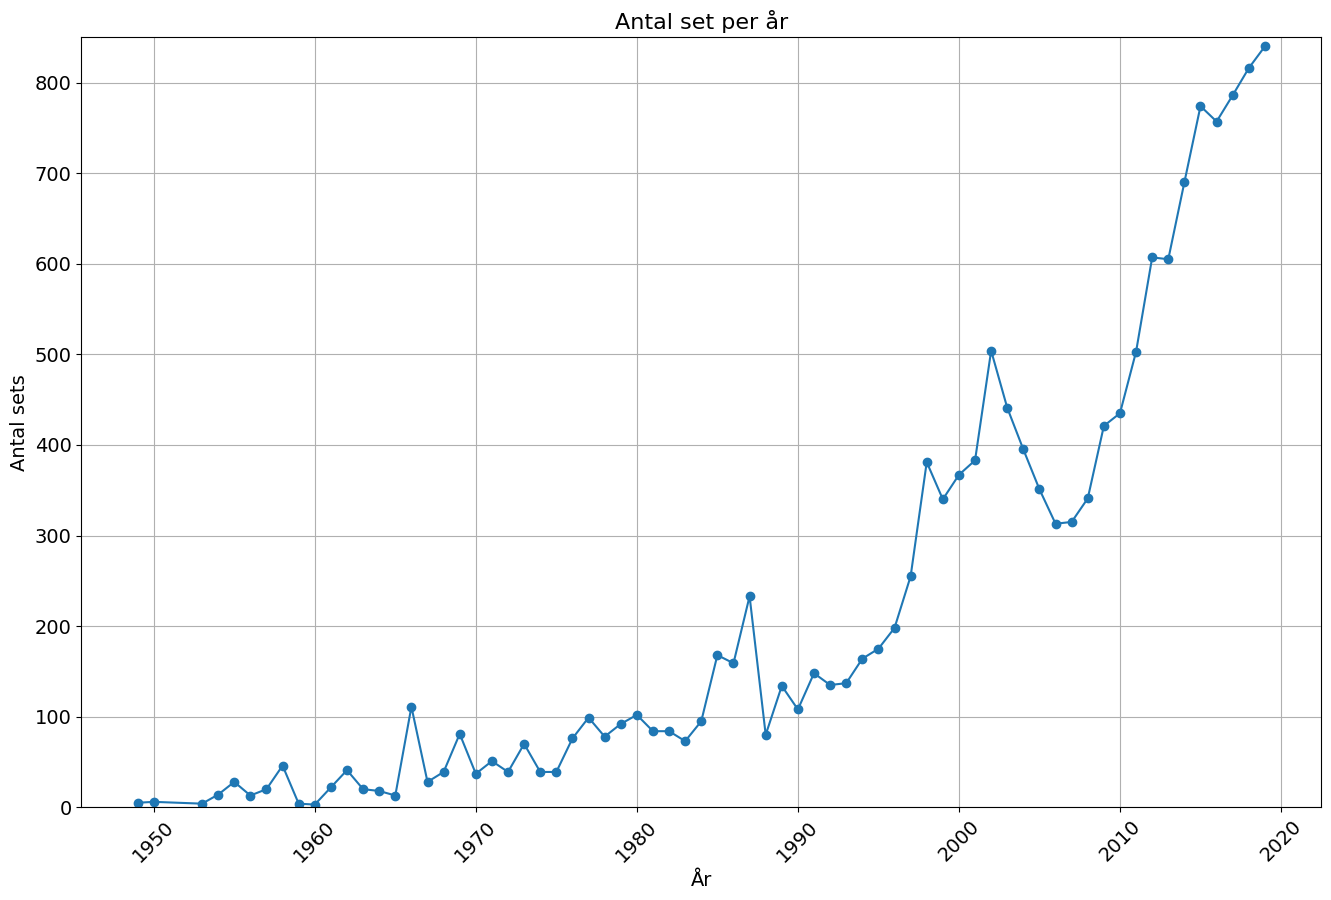

In [17]:

import matplotlib.pyplot as plt
year_filter = sets[(sets['year'] != 2020) & (sets['year'] != 2021)].groupby('year')['set_num'].count()

# Skapa figur
plt.figure(figsize=(16,10))
plt.plot(year_filter.index, year_filter.values, marker='o')
plt.xticks(fontsize=14, rotation=45)
plt.yticks(fontsize=14)
plt.xlabel('År', fontsize=14)
plt.ylabel('Antal sets', fontsize=14)
plt.ylim(0, year_filter.values.max() + 10)
plt.title('Antal set per år', fontsize=16)
plt.grid(True)
plt.show()



### Aggregate Data with the Python .agg() Function

Let's work out the number of different themes shipped by year. This means we have to count the number of unique theme_ids per calendar year.

In [25]:
unique_theme_year = sets[(sets['year'] != 2020) & (sets['year'] != 2021)].groupby('year').agg({"theme_id":"nunique"})
print("unika teman per år",unique_theme_year)

unika teman per år       theme_id
year          
1949         2
1950         1
1953         2
1954         2
1955         4
...        ...
2015        98
2016        92
2017        89
2018        93
2019        78

[69 rows x 1 columns]


**Challenge**: Plot the number of themes released by year on a line chart. Only include the full calendar years (i.e., exclude 2020 and 2021).

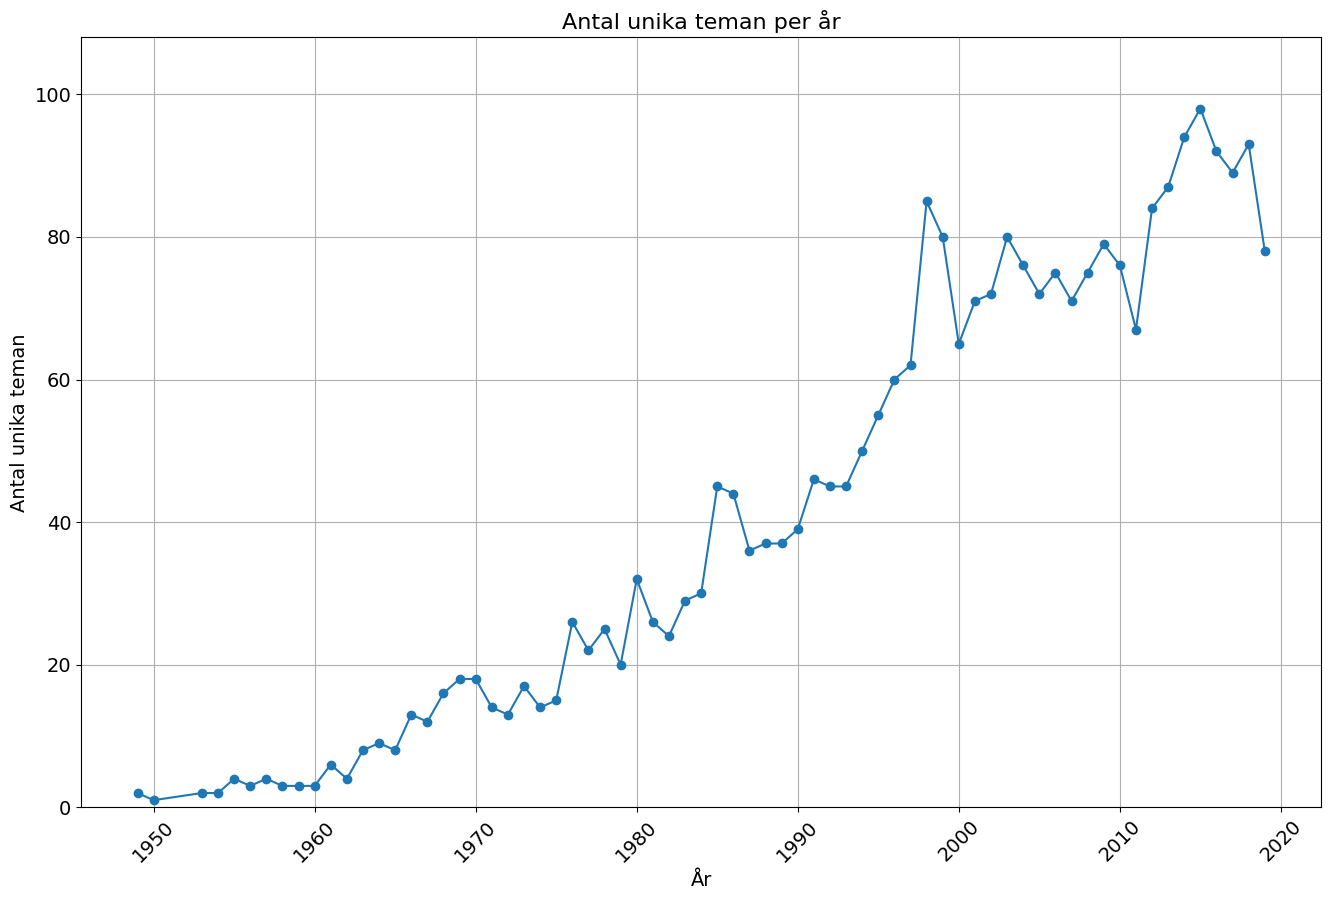

In [29]:

import matplotlib.pyplot as plt

# Skapa figur
plt.figure(figsize=(16,10))
plt.plot(unique_theme_year.index, unique_theme_year.values, marker='o')
plt.xticks(fontsize=14, rotation=45)
plt.yticks(fontsize=14)
plt.xlabel('År', fontsize=14)
plt.ylabel('Antal unika teman', fontsize=14)
plt.ylim(0, unique_theme_year.values.max() + 10)
plt.title('Antal unika teman per år', fontsize=16)
plt.grid(True)
plt.show()



**Challenge**: Use the <code>.groupby()</code> and <code>.agg()</code> function together to figure out the average number of parts per set. How many parts did the average LEGO set released in 1954 compared to say, 2017?

In [41]:
mean_parts = sets[(sets['year'] == 2017) | (sets['year'] == 1954)].groupby('year').agg({'num_parts': 'mean'})
print("medelantal delar per set per år", mean_parts)

medelantal delar per set per år        num_parts
year            
1954   12.357143
2017  221.840967


### Scatter Plots in Matplotlib

[länktext](https://)**Challenge**: Has the size and complexity of LEGO sets increased over time based on the number of parts? Plot the average number of parts over time using a Matplotlib scatter plot. See if you can use the [scatter plot documentation](https://matplotlib.org/3.1.0/api/_as_gen/matplotlib.pyplot.scatter.html) before I show you the solution. Do you spot a trend in the chart?

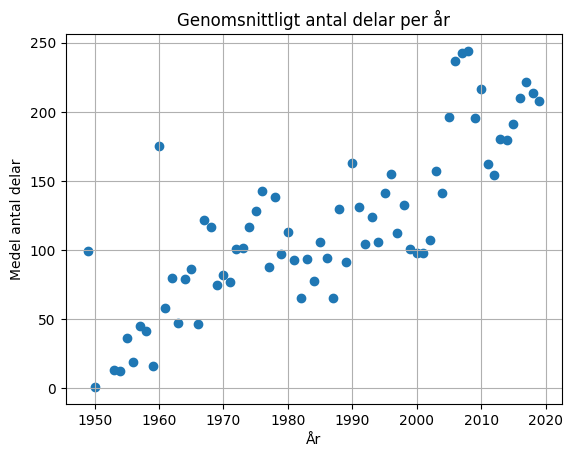

In [46]:
import matplotlib.pyplot as plt

mean_parts = sets[sets['year'] < 2020].groupby('year').agg({'num_parts': 'mean'})

x = mean_parts.index
y = mean_parts['num_parts']
plt.scatter(x, y)
plt.xlabel('År')
plt.ylabel('Medel antal delar')
plt.title('Genomsnittligt antal delar per år')
plt.grid(True)
plt.show()

### Number of Sets per LEGO Theme

LEGO has licensed many hit franchises from Harry Potter to Marvel Super Heros to many others. But which theme has the largest number of individual sets?

In [71]:
sets_per_theme = sets.groupby('theme_id') \
                     .agg({'set_num':'count'}) \
                     .sort_values(by='set_num', ascending=False) \
                     .head(1)
print(sets_per_theme)

          set_num
theme_id         
158           753


**Challenge** Use what you know about HTML markup and tags to display the database schema: https://i.imgur.com/Sg4lcjx.png

!["database"](https://i.imgur.com/Sg4lcjx.png)

### Database Schemas, Foreign Keys and Merging DataFrames

The themes.csv file has the actual theme names. The sets .csv has <code>theme_ids</code> which link to the <code>id</code> column in the themes.csv.

**Challenge**: Explore the themes.csv. How is it structured? Search for the name 'Star Wars'. How many <code>id</code>s correspond to this name in the themes.csv? Now use these <code>id</code>s and find the corresponding the sets in the sets.csv (Hint: you'll need to look for matches in the <code>theme_id</code> column)

In [92]:
themes = pd.read_csv("themes.csv")
star_wars_ids = themes[themes.name == "Star Wars"]["id"].tolist()

star_wars_sets = sets[sets['theme_id'].isin(star_wars_ids)].groupby("theme_id").size()
print("Antal set per Star Wars theme_id:", star_wars_sets.head())


Antal set per Star Wars theme_id: theme_id
18      11
158    753
209     10
261      2
dtype: int64


### Merging (i.e., Combining) DataFrames based on a Key


In [160]:
themes = pd.read_csv("themes.csv")

sets_per_theme = sets.groupby('theme_id').size()
min_theme = sets_per_theme.sort_values().head(1)
themes_filtered = themes[themes['id'] == min_theme.index[0]]
merged_df = pd.merge(themes_filtered, sets, left_on='id', right_on='theme_id')

print(f"Tema-id med minst antal set: {min_theme.index[0]}, Set: {merged_df["name_x"].head(1).values[0]}")

Tema-id med minst antal set: 512, Set: Castle


In [162]:
themes = pd.read_csv("themes.csv")

sets_per_theme = sets.groupby('theme_id').size()
max_theme = sets_per_theme.sort_values(ascending=False).head(1)
themes_filtered = themes[themes['id'] == max_theme.index[0]]
merged_df = pd.merge(themes_filtered, sets, left_on='id', right_on='theme_id')


print(f"Tema-id med flest antal set: {max_theme.index[0]}, Set: {merged_df["name_x"].head(1).values[0]}" )

Tema-id med flest antal set: 158, Set: Star Wars
